In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
#from pyfish import fish_plot, process_data, setup_figure

### Pairtree

build input files

In [ ]:
def build_pairtree_inputs(pat,iter):
    def compress_position(cols,df): # compress all cols for each position into a single string
        grouped = df.groupby('position')[cols].apply(lambda x: pd.Series({col: ','.join(x[col].astype(str)) for col in cols}), include_groups=False)
        return grouped.reset_index()



    # load snp df
    df_snp=pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t',usecols=['position','depth','DP4','lane','date','allele_freq'])
    df_snp['lane']=df_snp['lane']+'_'+df_snp['date']
    # filter snps
    # only keep snps in pyclone output
    pyclone_df=pd.read_csv(f'{pat}/mut_dyn/pyclone/pyclone_out_{pat}_iter{iter}.tsv',sep='\t',usecols=['mutation_id','cluster_id'],skiprows=1)
    pyclone_pos=pyclone_df['mutation_id'].map(lambda x: int(x.split('_')[1])).unique()
    df_snp=df_snp[df_snp['position'].isin(pyclone_pos)].copy()
    ## remove positions where allele_freq is always over 0.9
    #always_high = df_snp.groupby('position')['allele_freq'].transform(lambda x: (x > 0.9).all())
    ## remove positions where allele_freq is above 5% 1 time or less
    #only_once_over_5 = df_snp.groupby('position')['allele_freq'].transform(lambda x: (x > 0.05).sum() < 2)
    #df_snp = df_snp.loc[~always_high & ~only_once_over_5].copy()
    ## generate new info

    #df_snp['var_reads']=df_snp['DP4'].map(lambda x: int(x.split(',')[2])+int(x.split(',')[3]))
    #df_snp['var_read_prob']=1
    #df_snp.rename(columns={'depth':'total_reads'},inplace=True)
    # vectorized DP4 parsing -> var_reads
    dp4 = df_snp['DP4'].str.split(',', expand=True)
    dp4 = dp4.astype(int)
    df_snp['var_reads'] = dp4.iloc[:, 2] + dp4.iloc[:, 3]
    df_snp['var_read_prob'] = 1
    df_snp.rename(columns={'depth': 'total_reads'}, inplace=True)

    # create ssm
    # sort so that we have the same lane order for each position
    df_snp.sort_values(['position','lane'],inplace=True)
    
    # create new df
    # compress columns for each pos
    df_ssm=compress_position(['var_reads','var_read_prob','total_reads'], df_snp)
    df_ssm.rename(columns={'position':'name'},inplace=True)

    # create name col and edit id col
    df_ssm['name']=df_ssm['name'].map(lambda x: f'pos_{x}')
    df_ssm['id']=df_ssm.index.map(lambda x: f's{x}') # need unique ids for pairtree s0,s1,...
    df_ssm.to_csv(f'{pat}/mut_dyn/pairtree/ssm_{pat}.tsv',sep='\t',index=False)

    # create json
    json_dict={}
    # add samples to json
    json_dict['samples']=df_snp['lane'].unique().tolist()
    # add clusters to json
    pyclone_df.drop_duplicates(subset='mutation_id', inplace=True)
    name_to_id = dict(zip(df_ssm['name'], df_ssm['id']))
    pyclone_df['pairtree_id'] = pyclone_df['mutation_id'].map(name_to_id)
#    pyclone_df['pairtree_id']=pyclone_df['mutation_id'].map(lambda x: df_ssm[df_ssm['name']==x]['id'].values[0])
    clusters=[]
    for cluster_id in sorted(pyclone_df['cluster_id'].unique()):
        clusters.append(pyclone_df[pyclone_df.cluster_id==cluster_id]['pairtree_id'].tolist())
    json_dict['clusters']=clusters
    json_dict['garbage']= []
    with open(f'{pat}/mut_dyn/pairtree/json_{pat}.json','w') as f:
        json.dump(json_dict,f,indent=2)
    
    
build_pairtree_inputs('Papworth_28',2)

Run paitree:
- Identify garbage mutations: pairtree removegarbage 
- Run pairtree: pairtree
- Visualise candidate trees and posterior: summposterior
- Visualise highest posterior tree: plottree

Viz pairtree population freqs

(to do: Fix line plot to reflect missing dates, remove mislabelled dates)

Remove dates due to mislabeling: [Timestamp('2016-11-19 00:00:00')]


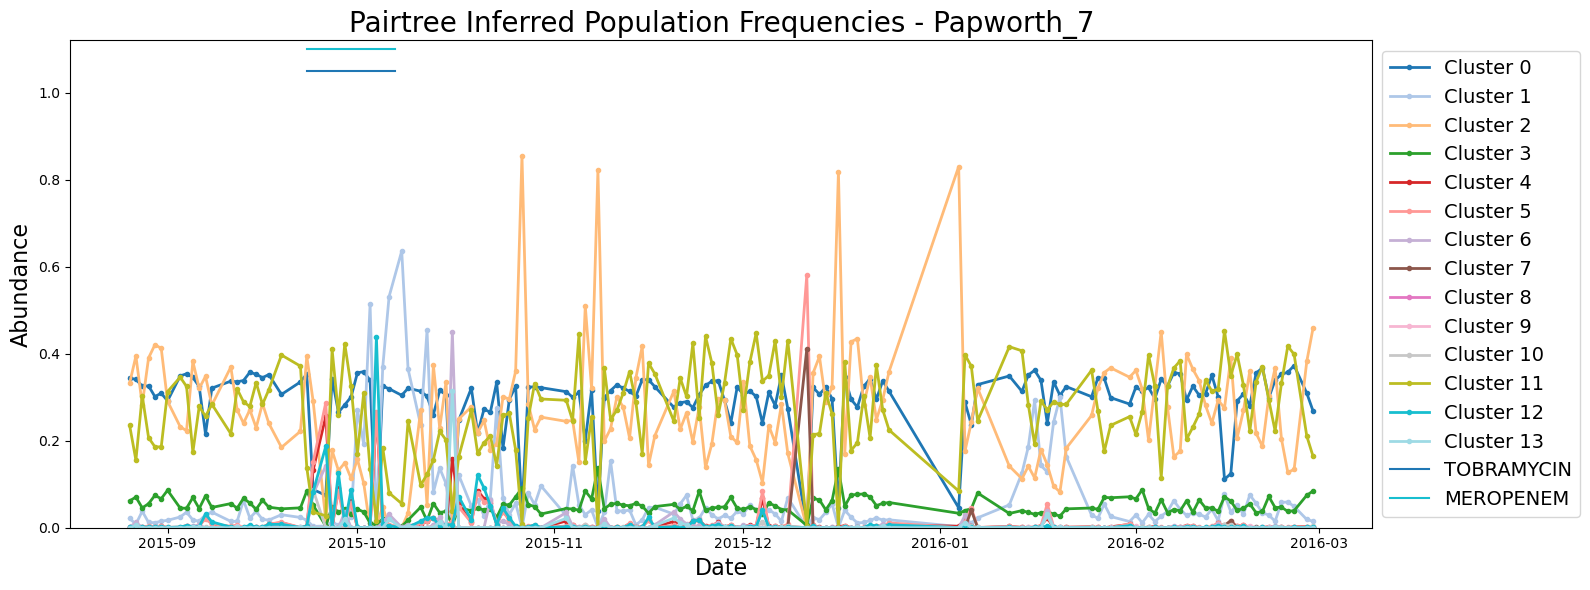

In [3]:
def get_ab(pat):
    # just cluster stuff together that is he same thing (same active ingredient/misspelled)
    ab_clust_dict1={"AZTREONAM":["ASTREONAM","AZTREONAM","AZTRONAM"],
             "ANTIFUNGAL":["ANTIFUNGAL CASPOFUNGIN","CASPOFUNGIN","ITRACONAZOLE","FLUCONAZOLE"],  
             "CO-TRIMOXAZOLE":["CO-TRIMOXAZOLE","SEPTRIN"], "COLISTIN":["COLISTIN","COLOMYCIN"], 
             "DOXYCYCLINE":["DOXYCYCLINE","DOXYCYLINE"], 
             "MISSING":["MISSING","MISSING2"]}
    #swap keys
    ab_clust_dict2={}
    for cluster in ab_clust_dict1:
        abs=ab_clust_dict1[cluster]
        for ab in abs:
            ab_clust_dict2[ab]=cluster
    #medication data location
    meds_data='SmartCare_pseudomona_data_for_javier_rename.xlsx'
    # Read the sheet for ABs during PE
    ab_meds_df = pd.read_excel(meds_data,sheet_name='SCPatientExacABs')
    #get rows matching patient
    ab_pat_df=ab_meds_df[ab_meds_df['J_ID'] == pat]
    ab_pat_df.sort_values(by='Start Date')
    #get unique ab
    unique_ab=ab_pat_df['Antibiotic Name'].unique()
    ab_data={}
    for ab in unique_ab:
        #identify cluster
        if ab.upper() in ab_clust_dict2.keys():
            ab_cluster=ab_clust_dict2[ab.upper()]
        else:
            ab_cluster=ab.upper()
        #check if already seen
        if ab_cluster in ab_data.keys():
            seen=True
        else:
            seen=False
        #Find ab entries
        ab_df=ab_pat_df[ab_pat_df['Antibiotic Name'] == ab]
        #get start and end dates 
        start_dates=ab_df['Start Date'].tolist()
        stop_dates=ab_df['Stop Date'].tolist()
        
        # if stop date is NaT replace with last sample date 
        for i in range(len(stop_dates)):
            if pd.isna(stop_dates[i]):
                stop_dates[i]=ab_meds_df['Stop Date'].max() # if no end date use last sample date
        if seen == False:
            ab_data[ab_cluster]=[start_dates,stop_dates]
        else:
            ab_data[ab_cluster][0].append(start_dates)
            ab_data[ab_cluster][1].append(stop_dates)
    
    return ab_data

def remove_mislabeled_dates(list_dates): # remove entries which probably have mislabeled dates, remove samples with less than 1 samples within 180 days either side
    
    to_remove=[]
    for i,date in enumerate(list_dates):
        if i>0:
            prev_date=list_dates[i-1]
        else:
            prev_date=date-pd.Timedelta(days=190)
        if i < len(list_dates)-1:
            next_date=list_dates[i+1]
        else:
            next_date=date+pd.Timedelta(days=190)
        #check difference
        diff_prev=(date - prev_date).days
        diff_next=(next_date - date).days
        if diff_prev > 180 and diff_next > 180:
            to_remove.append(date)
    #remove from df
    print(f'Remove dates due to mislabeling: {to_remove}')
    return to_remove

def plot_pop_freq(pat, plot_type='bar'):
    """
    Plot population frequencies from Pairtree output.
    
    Parameters:
    -----------
    pat : str
        Patient identifier
    plot_type : str, default='bar'
        Type of plot: 'bar' for stacked bar plot, 'line' for line graph
    """
    def plot_ab(pat,plot_type,start_height=1,date_x=None):
        ab_data = get_ab(pat)
        # check if ab_data is not empty
        if ab_data:
            height = start_height
            colors = plt.cm.tab10(np.linspace(0, 1, len(ab_data.keys())))
            for c, ab in enumerate(ab_data.keys()):
                height += 0.05
                start_dates = ab_data[ab][0]
                stop_dates = ab_data[ab][1]
                if plot_type == 'line':
                    for i in range(len(start_dates)):
                        plt.plot(pd.date_range(start=start_dates[i], end=stop_dates[i]), [height]*len(pd.date_range(start=start_dates[i], end=stop_dates[i])), label=ab if i == 0 else "",color=colors[c])
                elif plot_type == 'bar':
                    for i in range(len(start_dates)):
                        date_range=pd.date_range(start=start_dates[i], end=stop_dates[i])
                        x_positions = [date_x[date] for date in date_range]
                        plt.plot(x_positions, [height]*len(x_positions), label=ab if i == 0 else "", color=colors[c])
        
    # read pop freq and parents json from pairtree output
    with open(f'{pat}/mut_dyn/pairtree/plottree_{pat}.json', 'r') as f:
        json_dict = json.load(f)
    pop_freqs = np.array(json_dict['eta'])
    parents = json_dict['parents']
    # read samples from pairtree input json
    with open(f'{pat}/mut_dyn/pairtree/json_{pat}.json', 'r') as f:
        input_json_dict = json.load(f)
        samples = input_json_dict['samples']
    
    # currently samples are in lane_date format, convert to date only
    sample_dates = [pd.to_datetime(s.split('_')[-1], format='%d-%m-%Y') for s in samples]
    # sort by date and reorder pop_freqs accordingly
    date_sort_idx = np.argsort(sample_dates)
    sorted_dates = np.array(sample_dates)[date_sort_idx]
    pop_freqs_sorted = pop_freqs[:, date_sort_idx]
    
    # Handle duplicate dates by averaging their population frequencies
    unique_dates, inverse_indices = np.unique(sorted_dates, return_inverse=True)
    if len(unique_dates) < len(sorted_dates):
        # There are duplicates, need to average
        pop_freqs_averaged = np.zeros((pop_freqs_sorted.shape[0], len(unique_dates)))
        for i in range(len(unique_dates)):
            mask = inverse_indices == i
            pop_freqs_averaged[:, i] = pop_freqs_sorted[:, mask].mean(axis=1)
        sorted_dates = unique_dates
        pop_freqs_sorted = pop_freqs_averaged

    # remove mislabeled dates
    to_remove = remove_mislabeled_dates(sorted_dates)
    mask = ~np.isin(sorted_dates, to_remove)
    sorted_dates = sorted_dates[mask]
    pop_freqs_sorted = pop_freqs_sorted[:, mask]

    # Create a color palette with enough distinct colors
    n_clusters = pop_freqs_sorted.shape[0]
    colors = plt.cm.tab20(np.linspace(0, 1, min(n_clusters, 20))) if n_clusters <= 20 else plt.cm.hsv(np.linspace(0, 1, n_clusters))


    plt.figure(figsize=(16, 6))
    if plot_type == 'bar':
        # Stacked bar plot with gaps for missing dates
        # Create a complete date range from first to last date
        date_range = pd.date_range(start=sorted_dates[0], end=sorted_dates[-1], freq='D')
        
        # Create a mapping from actual dates to positions in the complete range
        date_to_pos = {date: i for i, date in enumerate(date_range)}
        x_positions = [date_to_pos[date] for date in sorted_dates]
        print(x_positions)
        
        # Plot bars at the correct positions
        bottom = np.zeros(len(x_positions))
        for i in range(n_clusters):
            plt.bar(x_positions, pop_freqs_sorted[i], bottom=bottom, 
                   color=colors[i], label=f'Cluster {i}', width=0.8, edgecolor='white', linewidth=0.5)
            bottom += pop_freqs_sorted[i]
        
        # Set x-axis limits and ticks
        plt.xlim(-0.5, len(date_range) - 0.5)
        num_ticks = min(15, len(date_range))
        tick_positions = np.linspace(0, len(date_range)-1, num_ticks, dtype=int)
        plt.xticks(tick_positions, [date_range[i].strftime('%Y-%m-%d') for i in tick_positions], 
                   rotation=45, ha='right')
        
        plot_ab(pat,plot_type='bar',start_height=1,date_x=date_to_pos)
        
    elif plot_type == 'line':
        # Line plot
        for i in range(n_clusters):
            plt.plot(sorted_dates, pop_freqs_sorted[i], color=colors[i], label=f'Cluster {i}', linewidth=2, marker='o', markersize=3)
        # plot antibiotic data
        plot_ab(pat,plot_type='line',start_height=1)
    
    elif plot_type == 'fish':
        # ger tree structure
        parent_tree=[]
        for child, parent in enumerate(parents):
            parent_tree.append([parent, child+1])
        parent_tree_df=pd.DataFrame(parent_tree,columns=["ParentId", "ChildId"])

        # get pop freq in format for fishplot. Cols: Id, Time, Pop Freq
        df_pop_freq = pd.DataFrame(pop_freqs_sorted).T
        df_pop_freq.columns = [i for i in range(pop_freqs_sorted.shape[0])]
        df_pop_freq['date'] = sorted_dates
        df_pyfish = df_pop_freq.melt(id_vars='date', var_name='Id', value_name='Pop')
        # Create a complete date range from first to last date
        date_range = pd.date_range(start=sorted_dates[0], end=sorted_dates[-1], freq='D')
        # Create a mapping from actual dates to positions in the complete range
        date_to_pos = {date: i for i, date in enumerate(date_range)}
        df_pyfish['Step'] = df_pyfish['date'].map(date_to_pos)
        df_pyfish.drop(columns=['date'],inplace=True)
        print(df_pyfish.head())
        
        # create fishplot
        data = process_data(df_pyfish, parent_tree_df)
        setup_figure()
        fish_plot(*data)
        plt.show()

        
    else:
        raise ValueError("plot_type must be 'bar' or 'line' or 'fish' ")

    if plot_type in ['bar', 'line']:
        plt.xlabel("Date", fontsize=16)
        plt.ylabel("Abundance", fontsize=16)
        plt.title(f'Pairtree Inferred Population Frequencies - {pat}', fontsize=20)
        plt.ylim(0, len(get_ab(pat))*0.06 + 1)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=14)
        plt.tight_layout()
        plt.show()

# Example usage
plot_pop_freq('Papworth_7', plot_type='line')

In [18]:
pat='Papworth_7'
with open(f'{pat}/mut_dyn/pairtree/plottree_{pat}.json', 'r') as f:
    input_json_dict = json.load(f)

parents = input_json_dict['parents']
parent_tree=[]
for child, parent in enumerate(parents):
    parent_tree.append([parent, child+1])
parent_tree_df=pd.DataFrame(parent_tree,columns=['parent','child'])

samples = input_json_dict['samples']
pop_freqs = np.array(input_json_dict['eta'])   

# currently samples are in lane_date format, convert to date only
sample_dates = [pd.to_datetime(s.split('_')[-1], format='%d-%m-%Y') for s in samples]
# sort by date and reorder pop_freqs accordingly
date_sort_idx = np.argsort(sample_dates)
sorted_dates = np.array(sample_dates)[date_sort_idx]
pop_freqs_sorted = pop_freqs[:, date_sort_idx]

# Convert to long format with index, date, and value columns
df_long = pd.DataFrame(pop_freqs_sorted).T
df_long.columns = [i for i in range(pop_freqs_sorted.shape[0])]
df_long['date'] = sorted_dates
df_melted = df_long.melt(id_vars='date', var_name='Id', value_name='Pop')
df_melted

,date,Id,Pop
0,2015-08-26,0,3.441149e-01
1,2015-08-27,0,3.407085e-01
2,2015-08-28,0,3.254516e-01
3,2015-08-29,0,3.259343e-01
4,2015-08-30,0,3.013902e-01
...,...,...,...
2137,2016-02-25,13,2.648027e-04
2138,2016-02-26,13,0.000000e+00
2139,2016-02-28,13,1.819291e-16
2140,2016-02-29,13,0.000000e+00


SNP Error Calculator (median depth 216)

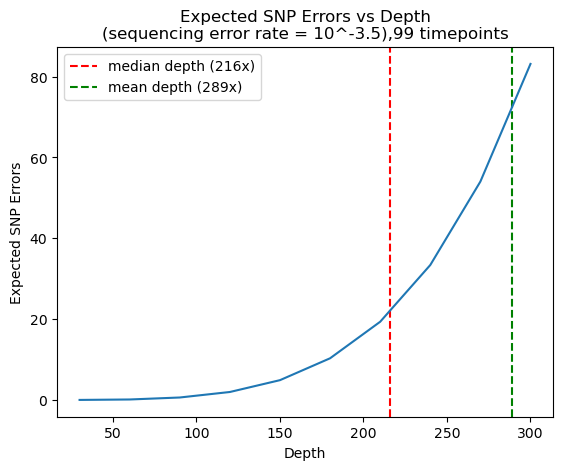

In [ ]:
from math import factorial
from math import comb
import numpy as np
import matplotlib.pyplot as plt

def calc_error(b,d):
    summ_list=[]
    for g in range(4,d-1):
        summ_list.append(((((1-b)**(d-1-g))*((b/3)**g)))*((1-b)/(d-g)+2*b)*comb(d-1,g))
    return ((b/3)**d + d*sum(summ_list))

def expected_snp_errors(b,d):
    return (3*calc_error(b, d))*(99*6300000)

x=np.linspace(30,300,10)
y=[expected_snp_errors(10**(-3.5), int(i)) for i in x]
plt.axvline(x=216, color='r', linestyle='--', label='median depth (216x)')
plt.axvline(x=289, color='g', linestyle='--', label='mean depth (289x)')
plt.xlabel('Depth')
plt.ylabel('Expected SNP Errors')
plt.title('Expected SNP Errors vs Depth\n(sequencing error rate = 10^-3.5),99 timepoints')
plt.legend()
plt.plot(x,y)

In [ ]:
from math import comb
comb(5,2)

10

In [12]:
p7_df=pd.read_csv('Papworth_7/mut_dyn/mut_evolution_dates.txt',sep='\t')

In [15]:
p7_df['date']=pd.to_datetime(p7_df['date'],format='%d-%m-%Y')

In [19]:
list(p7_df.sort_values('date').date.unique())

[Timestamp('2015-08-26 00:00:00'),
 Timestamp('2015-08-27 00:00:00'),
 Timestamp('2015-08-28 00:00:00'),
 Timestamp('2015-08-29 00:00:00'),
 Timestamp('2015-08-30 00:00:00'),
 Timestamp('2015-08-31 00:00:00'),
 Timestamp('2015-09-01 00:00:00'),
 Timestamp('2015-09-03 00:00:00'),
 Timestamp('2015-09-04 00:00:00'),
 Timestamp('2015-09-05 00:00:00'),
 Timestamp('2015-09-06 00:00:00'),
 Timestamp('2015-09-07 00:00:00'),
 Timestamp('2015-09-08 00:00:00'),
 Timestamp('2015-09-11 00:00:00'),
 Timestamp('2015-09-12 00:00:00'),
 Timestamp('2015-09-13 00:00:00'),
 Timestamp('2015-09-14 00:00:00'),
 Timestamp('2015-09-15 00:00:00'),
 Timestamp('2015-09-16 00:00:00'),
 Timestamp('2015-09-17 00:00:00'),
 Timestamp('2015-09-19 00:00:00'),
 Timestamp('2015-09-22 00:00:00'),
 Timestamp('2015-09-23 00:00:00'),
 Timestamp('2015-09-24 00:00:00'),
 Timestamp('2015-09-26 00:00:00'),
 Timestamp('2015-09-27 00:00:00'),
 Timestamp('2015-09-28 00:00:00'),
 Timestamp('2015-09-29 00:00:00'),
 Timestamp('2015-09-

In [11]:
pat='Papworth_7'
pyclone_df=pd.read_csv(f'{pat}/mut_dyn/pyclone/pyclone_out_{pat}_cleaned.tsv',sep='\t',usecols=['mutation_id','cluster_id'])
pyclone_df['mutation_id'].map(lambda x: int(x.split('_')[1])).unique()

array([1045614, 1046896, 1047754, ...,  960509,  962930,  976961])